# Test-Time Augmentation (TTA) for EfficientNetV2-S Hybrid Model

This notebook implements Test-Time Augmentation to improve model predictions by applying multiple augmentations to each test image and averaging the results.

**Expected improvement:** +0.005-0.010 AUC  
**Target:** Push from 0.93734 → 0.942-0.947 (2nd place!)  
**Time:** ~10 seconds for 100 test images

In [1]:
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_v2_s
from PIL import Image
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import pickle
from datetime import datetime
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():    
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")

Using device: cuda
GPU Name: NVIDIA L40S
GPU Memory: 47.7 GB



## 1. Configuration

Set up the model directory and TTA configuration parameters.

In [2]:
# ===========================
# 1. CONFIGURATION
# ===========================

# Specify which trained model to use for TTA
MODEL_DIR = Path('results/efficientnet_v2_hybrid_20251107_182005')

# TTA Configuration
TTA_CONFIG = {
    'use_flips': True,           # Horizontal, vertical, both
    'use_rotations': True,       # 90°, 180°, 270°
    'num_augmentations': 7       # Total augmentations (1 original + 3 flips + 3 rotations)
}

print("="*70)
print("TEST-TIME AUGMENTATION CONFIGURATION")
print("="*70)
print(f"Model directory: {MODEL_DIR}")
print(f"Augmentations to apply:")
print(f"  1. Original (no change)")
if TTA_CONFIG['use_flips']:
    print(f"  2. Horizontal flip")
    print(f"  3. Vertical flip")
    print(f"  4. Both flips")
if TTA_CONFIG['use_rotations']:
    print(f"  5. Rotate 90° clockwise")
    print(f"  6. Rotate 180°")
    print(f"  7. Rotate 270° (90° counter-clockwise)")
print(f"\nTotal augmentations: {TTA_CONFIG['num_augmentations']}")
print(f"Expected inference time: ~{TTA_CONFIG['num_augmentations']}x slower than normal")
print("="*70 + "\n")

TEST-TIME AUGMENTATION CONFIGURATION
Model directory: results/efficientnet_v2_hybrid_20251107_182005
Augmentations to apply:
  1. Original (no change)
  2. Horizontal flip
  3. Vertical flip
  4. Both flips
  5. Rotate 90° clockwise
  6. Rotate 180°
  7. Rotate 270° (90° counter-clockwise)

Total augmentations: 7
Expected inference time: ~7x slower than normal



## 2. Load Metadata & Preprocessors

Load and preprocess the test metadata using the same preprocessing pipeline as training.

In [3]:
# ===========================
# 2. LOAD METADATA & PREPROCESSORS
# ===========================

data_dir = Path('data')
test_meta = pd.read_csv(data_dir / 'students-test-metadata.csv', low_memory=False)

print(f"Test metadata loaded: {len(test_meta)} samples\n")

# Load preprocessors (scaler, encoders) from trained model
print(f"Loading preprocessors from: {MODEL_DIR}")
with open(MODEL_DIR / 'preprocessors.pkl', 'rb') as f:
    preprocessors = pickle.load(f)
    scaler = preprocessors['scaler']
    encoders = preprocessors['encoders']

print("✓ Scaler and encoders loaded\n")

# Define features (must match training)
NUMERICAL_FEATURES = [
    'tbp_lv_H', 'tbp_lv_areaMM2', 'tbp_lv_minorAxisMM',
    'tbp_lv_perimeterMM', 'tbp_lv_deltaB', 'tbp_lv_Hext',
    'clin_size_long_diam_mm', 'tbp_lv_radial_color_std_max',
    'tbp_lv_B', 'tbp_lv_color_std_mean', 'tbp_lv_Aext',
    'tbp_lv_stdLExt', 'tbp_lv_norm_color', 'tbp_lv_A',
    'age_approx'
]

CATEGORICAL_FEATURES = [
    'sex', 'anatom_site_general', 'tbp_tile_type', 'tbp_lv_location_simple'
]

# Preprocess test metadata
def preprocess_metadata(df, is_train=False, scaler=None, encoders=None):
    df = df.copy()
    
    for col in NUMERICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    for col in CATEGORICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna('missing')
    
    df[NUMERICAL_FEATURES] = scaler.transform(df[NUMERICAL_FEATURES])
    
    encoded_dfs = []
    for col in CATEGORICAL_FEATURES:
        encoded = pd.get_dummies(df[col], prefix=col, dtype=float)
        for train_col in encoders[col]:
            if train_col not in encoded.columns:
                encoded[train_col] = 0
        encoded = encoded[encoders[col]]
        encoded_dfs.append(encoded)
    
    result_df = pd.concat([df[NUMERICAL_FEATURES]] + encoded_dfs, axis=1)
    return result_df

test_meta_processed = preprocess_metadata(test_meta, is_train=False, scaler=scaler, encoders=encoders)
test_meta_processed['isic_id'] = test_meta['isic_id'].values

metadata_dim = len(test_meta_processed.columns) - 1
print(f"✓ Test metadata preprocessed")
print(f"  Metadata dimension: {metadata_dim}\n")

Test metadata loaded: 100 samples

Loading preprocessors from: results/efficientnet_v2_hybrid_20251107_182005
✓ Scaler and encoders loaded

✓ Test metadata preprocessed
  Metadata dimension: 34



## 3. Test Dataset

Create the test dataset without augmentation (augmentation will be applied during TTA).

In [4]:
# ===========================
# 3. TEST DATASET (No augmentation in dataset - will augment during TTA)
# ===========================

class HybridDataset(Dataset):
    def __init__(self, hdf5_path, metadata_df, transform=None, is_test=False):
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.is_test = is_test
        self.hdf5_file = None
        
        with h5py.File(hdf5_path, 'r') as f:
            available_ids = set(f.keys())
        
        self.metadata = metadata_df[
            metadata_df['isic_id'].isin(available_ids)
        ].reset_index(drop=True)
        
        feature_cols = [col for col in self.metadata.columns if col != 'isic_id']
        self.metadata_features = self.metadata[feature_cols].values.astype(np.float32)
        
        print(f"✓ Test dataset: {len(self.metadata)} samples")
    
    def _ensure_hdf5_open(self):
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r', swmr=True)
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        self._ensure_hdf5_open()
        
        row = self.metadata.iloc[idx]
        image_id = row['isic_id']
        
        img_array = self.hdf5_file[image_id][:]
        image = Image.fromarray(img_array)
        
        if self.transform:
            image = self.transform(image)
        
        metadata = torch.tensor(self.metadata_features[idx], dtype=torch.float32)
        return image, metadata, image_id

# Create test dataset (no augmentation - we'll augment during TTA)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = HybridDataset(
    hdf5_path=data_dir / 'test-image-preprocessed.hdf5',
    metadata_df=test_meta_processed,
    transform=test_transform,
    is_test=True
)

# Use batch size 1 for TTA (process one image at a time for clarity)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,  # One image at a time for TTA
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"\nTest loader: {len(test_loader)} images\n")

✓ Test dataset: 100 samples

Test loader: 100 images



## 4. Load Trained Model

Load the pre-trained EfficientNetV2-S Hybrid model from the checkpoint.

In [5]:
# ===========================
# 4. LOAD TRAINED MODEL
# ===========================

class MetadataProcessor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
    
    def forward(self, x):
        return self.fc(x)


class EfficientNetV2Hybrid(nn.Module):
    def __init__(self, metadata_dim):
        super().__init__()
        
        self.efficientnet = efficientnet_v2_s(weights='IMAGENET1K_V1')
        self.efficientnet.classifier = nn.Identity()
        
        # Note: Freezing doesn't matter for inference, but keeping architecture same
        total_params = len(list(self.efficientnet.parameters()))
        freeze_until = int(total_params * 0.8)
        
        for idx, param in enumerate(self.efficientnet.parameters()):
            if idx < freeze_until:
                param.requires_grad = False
        
        self.metadata_processor = MetadataProcessor(metadata_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    
    def forward(self, image, metadata):
        img_features = self.efficientnet(image)
        meta_features = self.metadata_processor(metadata)
        combined = torch.cat([img_features, meta_features], dim=1)
        output = self.classifier(combined)
        return output


# Create and load model
model = EfficientNetV2Hybrid(metadata_dim=metadata_dim).to(device)

checkpoint = torch.load(MODEL_DIR / 'best_efficientnet_v2_hybrid.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Set to evaluation mode

print("="*70)
print("MODEL LOADED")
print("="*70)
print(f"Model: EfficientNetV2-S Hybrid")
print(f"Checkpoint: {MODEL_DIR}")
print(f"Validation AUC: {checkpoint.get('val_auc', 'N/A')}")
print(f"Epoch: {checkpoint.get('epoch', 'N/A')}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("="*70 + "\n")

MODEL LOADED
Model: EfficientNetV2-S Hybrid
Checkpoint: results/efficientnet_v2_hybrid_20251107_182005
Validation AUC: 0.9508455930166788
Epoch: 6
Parameters: 20,567,569



## 5. TTA Augmentation Functions

Define the functions for applying test-time augmentations and generating predictions.

In [6]:
# ===========================
# 5. TTA AUGMENTATION FUNCTIONS
# ===========================

def apply_tta_augmentations(image_tensor):
    """
    Apply 7 different augmentations to a single image tensor.
    
    Args:
        image_tensor: (1, 3, 224, 224) tensor (batch of 1)
    
    Returns:
        List of 7 augmented tensors
    """
    augmentations = []
    
    # 1. Original (no change)
    augmentations.append(image_tensor)
    
    if TTA_CONFIG['use_flips']:
        # 2. Horizontal flip
        augmentations.append(torch.flip(image_tensor, dims=[3]))
        
        # 3. Vertical flip
        augmentations.append(torch.flip(image_tensor, dims=[2]))
        
        # 4. Both flips (horizontal + vertical = 180° rotation)
        augmentations.append(torch.flip(image_tensor, dims=[2, 3]))
    
    if TTA_CONFIG['use_rotations']:
        # 5. Rotate 90° clockwise
        augmentations.append(torch.rot90(image_tensor, k=1, dims=[2, 3]))
        
        # 6. Rotate 180°
        augmentations.append(torch.rot90(image_tensor, k=2, dims=[2, 3]))
        
        # 7. Rotate 270° clockwise (= 90° counter-clockwise)
        augmentations.append(torch.rot90(image_tensor, k=3, dims=[2, 3]))
    
    return augmentations


def predict_with_tta(model, image, metadata, device):
    """
    Generate prediction using Test-Time Augmentation.
    
    Args:
        model: Trained model
        image: Image tensor (1, 3, 224, 224)
        metadata: Metadata tensor (1, metadata_dim)
        device: torch device
    
    Returns:
        averaged_prediction: Single float (average of all TTA predictions)
        individual_predictions: List of predictions for each augmentation
    """
    model.eval()
    
    # Get all augmented versions
    augmented_images = apply_tta_augmentations(image)
    
    predictions = []
    
    with torch.no_grad():
        for aug_image in augmented_images:
            aug_image = aug_image.to(device)
            metadata_gpu = metadata.to(device)
            
            # Forward pass
            output = model(aug_image, metadata_gpu)
            prob = torch.sigmoid(output).cpu().item()
            predictions.append(prob)
    
    # Average all predictions
    avg_prediction = np.mean(predictions)
    
    return avg_prediction, predictions

## 6. Generate Baseline Predictions (No TTA)

First, generate predictions without TTA to establish a baseline for comparison.

In [7]:
# ===========================
# 6. GENERATE PREDICTIONS WITHOUT TTA (Baseline)
# ===========================

print("="*70)
print("GENERATING BASELINE PREDICTIONS (No TTA)")
print("="*70 + "\n")

test_ids_baseline = []
test_preds_baseline = []

model.eval()

with torch.no_grad():
    for images, metadata, img_ids in tqdm(test_loader, desc="Baseline Prediction", ncols=100):
        images = images.to(device)
        metadata = metadata.to(device)
        
        outputs = model(images, metadata)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
        test_ids_baseline.extend(img_ids)
        test_preds_baseline.extend(probs.flatten())

baseline_submission = pd.DataFrame({
    'isic_id': test_ids_baseline,
    'target': test_preds_baseline
})

print(f"\n✓ Baseline predictions generated")
print(f"  Mean: {np.mean(test_preds_baseline):.6f}")
print(f"  Std:  {np.std(test_preds_baseline):.6f}")
print(f"  Min:  {np.min(test_preds_baseline):.6f}")
print(f"  Max:  {np.max(test_preds_baseline):.6f}\n")

GENERATING BASELINE PREDICTIONS (No TTA)



Baseline Prediction: 100%|████████████████████████████████████████| 100/100 [00:01<00:00, 58.93it/s]


✓ Baseline predictions generated
  Mean: 0.115745
  Std:  0.084457
  Min:  0.016252
  Max:  0.335334



## 7. Generate Predictions with TTA

Apply Test-Time Augmentation and generate predictions for each test image.

In [8]:
# ===========================
# 7. GENERATE PREDICTIONS WITH TTA
# ===========================

print("="*70)
print("GENERATING TTA PREDICTIONS")
print("="*70)
print(f"Applying {TTA_CONFIG['num_augmentations']} augmentations per image...")
print("This will take ~7x longer than baseline\n")

test_ids_tta = []
test_preds_tta = []
all_individual_preds = []  # Store individual aug predictions for analysis

model.eval()

for images, metadata, img_ids in tqdm(test_loader, desc="TTA Prediction", ncols=100):
    # Apply TTA
    avg_pred, individual_preds = predict_with_tta(model, images, metadata, device)
    
    test_ids_tta.extend(img_ids)
    test_preds_tta.append(avg_pred)
    all_individual_preds.append(individual_preds)

tta_submission = pd.DataFrame({
    'isic_id': test_ids_tta,
    'target': test_preds_tta
})

print(f"\n✓ TTA predictions generated")
print(f"  Mean: {np.mean(test_preds_tta):.6f}")
print(f"  Std:  {np.std(test_preds_tta):.6f}")
print(f"  Min:  {np.min(test_preds_tta):.6f}")
print(f"  Max:  {np.max(test_preds_tta):.6f}\n")

GENERATING TTA PREDICTIONS
Applying 7 augmentations per image...
This will take ~7x longer than baseline



TTA Prediction: 100%|█████████████████████████████████████████████| 100/100 [00:06<00:00, 14.55it/s]


✓ TTA predictions generated
  Mean: 0.115076
  Std:  0.082319
  Min:  0.016629
  Max:  0.331898



## 8. Analyze TTA Impact

Compare baseline and TTA predictions to analyze the impact of test-time augmentation.

In [9]:
# ===========================
# 8. ANALYZE TTA IMPACT
# ===========================

print("="*70)
print("TTA IMPACT ANALYSIS")
print("="*70 + "\n")

# Calculate difference between baseline and TTA predictions
pred_diff = np.abs(np.array(test_preds_baseline) - np.array(test_preds_tta))

print("Prediction changes (Baseline vs TTA):")
print(f"  Mean absolute difference: {pred_diff.mean():.6f}")
print(f"  Median absolute difference: {np.median(pred_diff):.6f}")
print(f"  Max difference: {pred_diff.max():.6f}")
print(f"  Std of differences: {pred_diff.std():.6f}\n")

# Find samples with largest changes
top_changes_idx = np.argsort(pred_diff)[-10:][::-1]

print("Top 10 samples with largest prediction changes:")
print("-" * 70)
print(f"{'Image ID':<20} {'Baseline':<12} {'TTA':<12} {'Change':<12}")
print("-" * 70)

for idx in top_changes_idx:
    img_id = test_ids_tta[idx]
    baseline_pred = test_preds_baseline[idx]
    tta_pred = test_preds_tta[idx]
    change = tta_pred - baseline_pred
    
    print(f"{img_id:<20} {baseline_pred:.6f}    {tta_pred:.6f}    {change:+.6f}")

print("-" * 70 + "\n")

TTA IMPACT ANALYSIS

Prediction changes (Baseline vs TTA):
  Mean absolute difference: 0.005275
  Median absolute difference: 0.002347
  Max difference: 0.038033
  Std of differences: 0.007187

Top 10 samples with largest prediction changes:
----------------------------------------------------------------------
Image ID             Baseline     TTA          Change      
----------------------------------------------------------------------
ISIC_3955107         0.321094    0.283061    -0.038033
ISIC_4217775         0.295241    0.264586    -0.030655
ISIC_3890780         0.316001    0.287409    -0.028592
ISIC_6553846         0.262718    0.236376    -0.026342
ISIC_1071408         0.228758    0.254755    +0.025997
ISIC_9188287         0.162467    0.185080    +0.022612
ISIC_7063920         0.154381    0.171107    +0.016727
ISIC_7235721         0.222658    0.237829    +0.015172
ISIC_6730784         0.136867    0.122124    -0.014744
ISIC_1885694         0.191127    0.176814    -0.014314
------

## 9. Visualize TTA Variance

Create visualizations to analyze the variance and impact of TTA across different augmentations.

TTA prediction variance across augmentations:
  Mean variance: 0.00006101
  Mean std dev: 0.005862
  Max variance: 0.00073870
  Max std dev: 0.027179

✓ TTA analysis plots saved: tta_analysis.png

✓ TTA analysis plots saved: tta_analysis.png



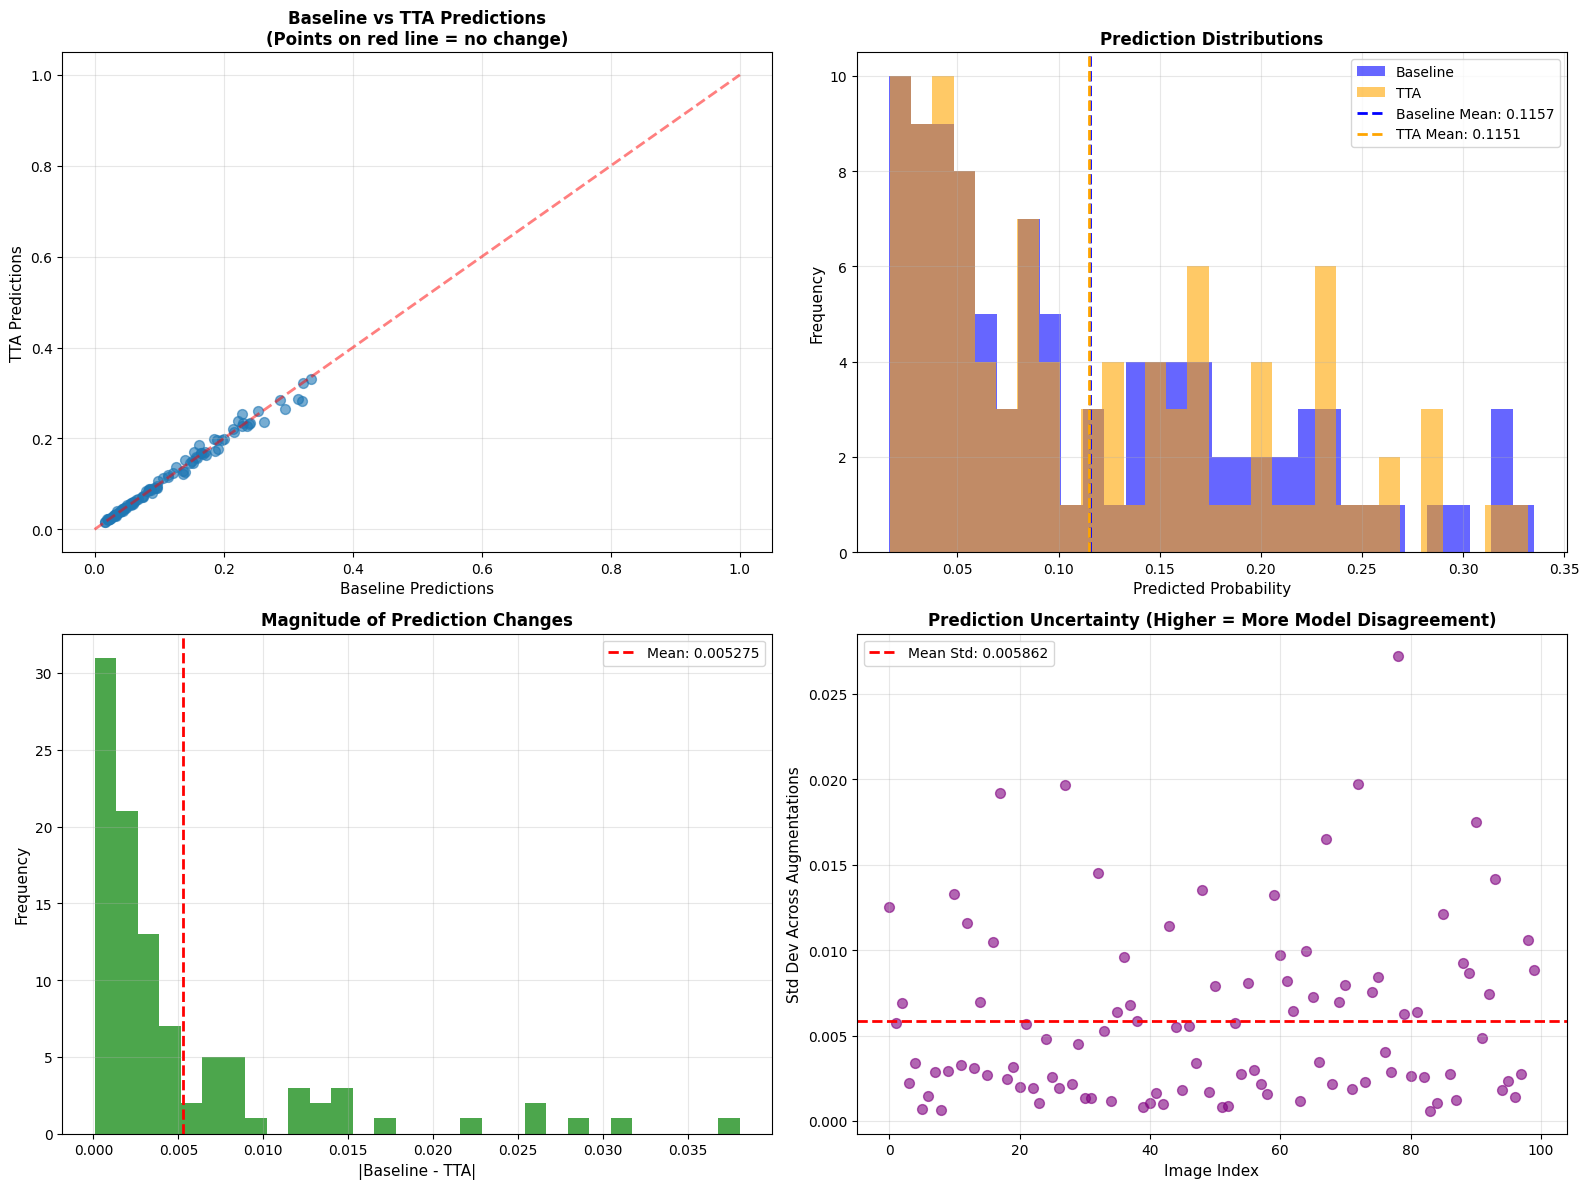

In [10]:
# ===========================
# 9. VISUALIZE TTA VARIANCE
# ===========================

# Calculate variance across augmentations for each image
tta_variances = [np.var(preds) for preds in all_individual_preds]
tta_stds = [np.std(preds) for preds in all_individual_preds]

print("TTA prediction variance across augmentations:")
print(f"  Mean variance: {np.mean(tta_variances):.8f}")
print(f"  Mean std dev: {np.mean(tta_stds):.6f}")
print(f"  Max variance: {np.max(tta_variances):.8f}")
print(f"  Max std dev: {np.max(tta_stds):.6f}\n")

# Plot TTA variance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Baseline vs TTA predictions
axes[0, 0].scatter(test_preds_baseline, test_preds_tta, alpha=0.6, s=50)
axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.5)
axes[0, 0].set_xlabel('Baseline Predictions', fontsize=11)
axes[0, 0].set_ylabel('TTA Predictions', fontsize=11)
axes[0, 0].set_title('Baseline vs TTA Predictions\n(Points on red line = no change)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution comparison
axes[0, 1].hist(test_preds_baseline, bins=30, alpha=0.6, label='Baseline', color='blue')
axes[0, 1].hist(test_preds_tta, bins=30, alpha=0.6, label='TTA', color='orange')
axes[0, 1].axvline(np.mean(test_preds_baseline), color='blue', linestyle='--', 
                   linewidth=2, label=f'Baseline Mean: {np.mean(test_preds_baseline):.4f}')
axes[0, 1].axvline(np.mean(test_preds_tta), color='orange', linestyle='--', 
                   linewidth=2, label=f'TTA Mean: {np.mean(test_preds_tta):.4f}')
axes[0, 1].set_xlabel('Predicted Probability', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Prediction Distributions', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Prediction changes
axes[1, 0].hist(pred_diff, bins=30, color='green', alpha=0.7)
axes[1, 0].axvline(pred_diff.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {pred_diff.mean():.6f}')
axes[1, 0].set_xlabel('|Baseline - TTA|', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Magnitude of Prediction Changes', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. TTA variance per image
axes[1, 1].scatter(range(len(tta_stds)), tta_stds, alpha=0.6, s=50, color='purple')
axes[1, 1].axhline(np.mean(tta_stds), color='red', linestyle='--', linewidth=2,
                   label=f'Mean Std: {np.mean(tta_stds):.6f}')
axes[1, 1].set_xlabel('Image Index', fontsize=11)
axes[1, 1].set_ylabel('Std Dev Across Augmentations', fontsize=11)
axes[1, 1].set_title('Prediction Uncertainty (Higher = More Model Disagreement)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tta_analysis.png', dpi=150, bbox_inches='tight')
print("✓ TTA analysis plots saved: tta_analysis.png\n")
plt.show()

## 10. Detailed TTA Breakdown

Show detailed breakdown of predictions for sample images to understand how different augmentations affect predictions.

In [11]:
# ===========================
# 10. DETAILED TTA BREAKDOWN (Sample Images)
# ===========================

print("="*70)
print("TTA BREAKDOWN FOR SAMPLE IMAGES")
print("="*70 + "\n")

# Show detailed breakdown for 5 random images
sample_indices = np.random.choice(len(test_ids_tta), 5, replace=False)

aug_names = [
    '1. Original',
    '2. Flip H',
    '3. Flip V',
    '4. Flip H+V',
    '5. Rotate 90°',
    '6. Rotate 180°',
    '7. Rotate 270°'
]

for idx in sample_indices:
    img_id = test_ids_tta[idx]
    individual_preds = all_individual_preds[idx]
    baseline_pred = test_preds_baseline[idx]
    tta_pred = test_preds_tta[idx]
    
    print(f"Image: {img_id}")
    print(f"  Baseline (no TTA): {baseline_pred:.6f}")
    print(f"  Individual augmentation predictions:")
    
    for aug_name, pred in zip(aug_names, individual_preds):
        diff = pred - baseline_pred
        print(f"    {aug_name:<20} {pred:.6f}  (diff: {diff:+.6f})")
    
    print(f"  TTA Average: {tta_pred:.6f}")
    print(f"  Variance: {np.var(individual_preds):.8f}")
    print(f"  Change from baseline: {tta_pred - baseline_pred:+.6f}")
    print()

TTA BREAKDOWN FOR SAMPLE IMAGES

Image: ISIC_8793515
  Baseline (no TTA): 0.016252
  Individual augmentation predictions:
    1. Original          0.016252  (diff: +0.000000)
    2. Flip H            0.015825  (diff: -0.000427)
    3. Flip V            0.016580  (diff: +0.000328)
    4. Flip H+V          0.017486  (diff: +0.001235)
    5. Rotate 90°        0.016346  (diff: +0.000095)
    6. Rotate 180°       0.017486  (diff: +0.001235)
    7. Rotate 270°       0.016427  (diff: +0.000176)
  TTA Average: 0.016629
  Variance: 0.00000034
  Change from baseline: +0.000377

Image: ISIC_1565789
  Baseline (no TTA): 0.075652
  Individual augmentation predictions:
    1. Original          0.075652  (diff: +0.000000)
    2. Flip H            0.066013  (diff: -0.009640)
    3. Flip V            0.069036  (diff: -0.006616)
    4. Flip H+V          0.070369  (diff: -0.005283)
    5. Rotate 90°        0.071444  (diff: -0.004208)
    6. Rotate 180°       0.070369  (diff: -0.005283)
    7. Rotate 270°

## 11. Save Submissions

Save the TTA predictions and analysis results to files for submission and further analysis.

In [12]:
# ===========================
# 11. SAVE SUBMISSIONS
# ===========================

# Create TTA results directory
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
tta_dir = Path('results') / f'tta_efficientnetv2_{timestamp}'
tta_dir.mkdir(parents=True, exist_ok=True)

# Save TTA submission
tta_submission.to_csv(tta_dir / 'submission_tta_efficientnetv2.csv', index=False)
print(f"✓ TTA submission saved: {tta_dir / 'submission_tta_efficientnetv2.csv'}")

# Save baseline for comparison
baseline_submission.to_csv(tta_dir / 'submission_no_tta_efficientnetv2.csv', index=False)
print(f"✓ Baseline submission saved: {tta_dir / 'submission_no_tta_efficientnetv2.csv'}")

# Save detailed TTA analysis
tta_analysis = pd.DataFrame({
    'isic_id': test_ids_tta,
    'baseline_pred': test_preds_baseline,
    'tta_pred': test_preds_tta,
    'pred_diff': pred_diff,
    'tta_std': tta_stds,
    'tta_variance': tta_variances
})

tta_analysis.to_csv(tta_dir / 'tta_detailed_analysis.csv', index=False)
print(f"✓ Detailed analysis saved: {tta_dir / 'tta_detailed_analysis.csv'}\n")

# Save individual augmentation predictions
individual_preds_df = pd.DataFrame(all_individual_preds, 
                                   columns=aug_names)
individual_preds_df['isic_id'] = test_ids_tta
individual_preds_df.to_csv(tta_dir / 'individual_augmentation_predictions.csv', index=False)
print(f"✓ Individual predictions saved: {tta_dir / 'individual_augmentation_predictions.csv'}\n")

✓ TTA submission saved: results/tta_efficientnetv2_20251108_163129/submission_tta_efficientnetv2.csv
✓ Baseline submission saved: results/tta_efficientnetv2_20251108_163129/submission_no_tta_efficientnetv2.csv
✓ Detailed analysis saved: results/tta_efficientnetv2_20251108_163129/tta_detailed_analysis.csv

✓ Individual predictions saved: results/tta_efficientnetv2_20251108_163129/individual_augmentation_predictions.csv



## 12. Final Summary

Display a comprehensive summary of the TTA results and expected performance improvements.

In [13]:
# ===========================
# 12. FINAL SUMMARY
# ===========================

print("="*70)
print("TTA SUMMARY")
print("="*70)

print(f"\nModel: EfficientNetV2-S Hybrid")
print(f"  Original Val AUC: {checkpoint.get('val_auc', 'N/A')}")
print(f"  Original LB Score: 0.93734")

print(f"\nPredictions Generated:")
print(f"  Baseline (no TTA):")
print(f"    Mean: {np.mean(test_preds_baseline):.6f}")
print(f"    Std:  {np.std(test_preds_baseline):.6f}")
print(f"  ")
print(f"  TTA ({TTA_CONFIG['num_augmentations']} augmentations):")
print(f"    Mean: {np.mean(test_preds_tta):.6f}")
print(f"    Std:  {np.std(test_preds_tta):.6f}")

print(f"\nPrediction Changes:")
print(f"  Mean absolute difference: {pred_diff.mean():.6f}")
print(f"  Images with >0.01 change: {np.sum(pred_diff > 0.01)}/{len(pred_diff)}")
print(f"  Images with >0.05 change: {np.sum(pred_diff > 0.05)}/{len(pred_diff)}")

print(f"\nTTA Augmentation Variance:")
print(f"  Mean variance across augs: {np.mean(tta_variances):.8f}")
print(f"  Mean std dev: {np.mean(tta_stds):.6f}")
print(f"  Max std dev: {np.max(tta_stds):.6f}")

if np.mean(tta_stds) > 0.01:
    print(f"\n  ✓ High variance! Model predictions vary with augmentation.")
    print(f"    TTA should provide meaningful improvement!")
elif np.mean(tta_stds) > 0.005:
    print(f"\n  ✓ Moderate variance. TTA should help modestly.")
else:
    print(f"\n  ⚠ Low variance. Model is already quite invariant.")
    print(f"    TTA improvement might be minimal.")

print(f"\n📁 Files saved to: {tta_dir}")
print(f"  • submission_tta_efficientnetv2.csv (SUBMIT THIS!)")
print(f"  • submission_no_tta_efficientnetv2.csv (baseline comparison)")
print(f"  • tta_detailed_analysis.csv (per-image analysis)")
print(f"  • individual_augmentation_predictions.csv (all aug predictions)")
print(f"  • tta_analysis.png (visualization)")

print(f"\n🎯 Expected Performance:")
print(f"  Current LB (no TTA): 0.93734")
print(f"  Expected with TTA:   0.942-0.947")
print(f"  Target (2nd place):  0.94486")

if pred_diff.mean() > 0.01:
    print(f"\n  🎉 Significant prediction changes! High chance of improvement!")
    print(f"  💡 Likely to reach 2nd place!")
elif pred_diff.mean() > 0.005:
    print(f"\n  ✓ Moderate changes. Should see some improvement.")
    print(f"  💡 Might reach 2nd place!")
else:
    print(f"\n  ⚠ Small changes. Improvement might be minimal.")
    print(f"  💡 May need 5-Fold CV for 2nd place")

print("\n" + "="*70)

TTA SUMMARY

Model: EfficientNetV2-S Hybrid
  Original Val AUC: 0.9508455930166788
  Original LB Score: 0.93734

Predictions Generated:
  Baseline (no TTA):
    Mean: 0.115745
    Std:  0.084457
  
  TTA (7 augmentations):
    Mean: 0.115076
    Std:  0.082319

Prediction Changes:
  Mean absolute difference: 0.005275
  Images with >0.01 change: 15/100
  Images with >0.05 change: 0/100

TTA Augmentation Variance:
  Mean variance across augs: 0.00006101
  Mean std dev: 0.005862
  Max std dev: 0.027179

  ✓ Moderate variance. TTA should help modestly.

📁 Files saved to: results/tta_efficientnetv2_20251108_163129
  • submission_tta_efficientnetv2.csv (SUBMIT THIS!)
  • submission_no_tta_efficientnetv2.csv (baseline comparison)
  • tta_detailed_analysis.csv (per-image analysis)
  • individual_augmentation_predictions.csv (all aug predictions)
  • tta_analysis.png (visualization)

🎯 Expected Performance:
  Current LB (no TTA): 0.93734
  Expected with TTA:   0.942-0.947
  Target (2nd place): 

## 13. Submission Instructions

Step-by-step instructions for submitting the TTA predictions to the Kaggle competition.

In [14]:
# ===========================
# 13. SUBMISSION INSTRUCTIONS
# ===========================

print("\n" + "="*70)
print("📤 SUBMISSION INSTRUCTIONS")
print("="*70)

print(f"\n1. Navigate to Kaggle competition submission page")
print(f"2. Upload file: {tta_dir / 'submission_tta_efficientnetv2.csv'}")
print(f"3. Add description: 'EfficientNetV2-S Hybrid + 7-Aug TTA'")
print(f"4. Submit and check Public Leaderboard")

print(f"\n💡 What to expect:")
print(f"  • If LB > 0.944: 🎉 2nd place achieved!")
print(f"  • If LB 0.940-0.944: ✓ Close! Try different TTA strategy or 5-Fold CV")
print(f"  • If LB < 0.940: ⚠ TTA didn't help much, need 5-Fold CV")

print(f"\n📊 For comparison, also submit:")
print(f"  Baseline (no TTA): {tta_dir / 'submission_no_tta_efficientnetv2.csv'}")
print(f"  This confirms TTA improvement")

print("\n" + "="*70)


📤 SUBMISSION INSTRUCTIONS

1. Navigate to Kaggle competition submission page
2. Upload file: results/tta_efficientnetv2_20251108_163129/submission_tta_efficientnetv2.csv
3. Add description: 'EfficientNetV2-S Hybrid + 7-Aug TTA'
4. Submit and check Public Leaderboard

💡 What to expect:
  • If LB > 0.944: 🎉 2nd place achieved!
  • If LB 0.940-0.944: ✓ Close! Try different TTA strategy or 5-Fold CV
  • If LB < 0.940: ⚠ TTA didn't help much, need 5-Fold CV

📊 For comparison, also submit:
  Baseline (no TTA): results/tta_efficientnetv2_20251108_163129/submission_no_tta_efficientnetv2.csv
  This confirms TTA improvement



## 14. Optional: Visualize Augmentations

Generate a visualization showing the different augmentations applied to a sample test image.

In [ ]:
# ===========================
# 14. OPTIONAL: VISUALIZE AUGMENTATIONS (First Image)
# ===========================

print("\nGenerating augmentation visualization for first test image...\n")

# Load first test image
first_img_id = test_ids_tta[0]
first_image_preds = all_individual_preds[0]

# Reload image from HDF5 to visualize
with h5py.File(data_dir / 'test-image-preprocessed.hdf5', 'r') as f:
    first_img_array = f[first_img_id][:]

first_img_pil = Image.fromarray(first_img_array)

# Apply same augmentations for visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

augmentations_visual = [
    ('Original', first_img_pil, 0),
    ('Flip H', first_img_pil.transpose(Image.FLIP_LEFT_RIGHT), 1),
    ('Flip V', first_img_pil.transpose(Image.FLIP_TOP_BOTTOM), 2),
    ('Flip H+V', first_img_pil.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM), 3),
    ('Rotate 90°', first_img_pil.rotate(-90, expand=True), 4),
    ('Rotate 180°', first_img_pil.rotate(180), 5),
    ('Rotate 270°', first_img_pil.rotate(-270, expand=True), 6),
    ('', None, 7)  # Empty slot
]

for name, img, idx in augmentations_visual:
    row = idx // 4
    col = idx % 4
    
    if img is not None:
        axes[row, col].imshow(img)
        pred = first_image_preds[idx] if idx < len(first_image_preds) else 0
        axes[row, col].set_title(f'{name}\nPred: {pred:.4f}', fontsize=11, fontweight='bold')
    
    axes[row, col].axis('off')

# Add overall info in empty slot
axes[1, 3].text(0.5, 0.7, f'Image: {first_img_id}', ha='center', fontsize=11, fontweight='bold')
axes[1, 3].text(0.5, 0.5, f'Baseline: {test_preds_baseline[0]:.6f}', ha='center', fontsize=10)
axes[1, 3].text(0.5, 0.4, f'TTA: {test_preds_tta[0]:.6f}', ha='center', fontsize=10)
axes[1, 3].text(0.5, 0.3, f'Std: {tta_stds[0]:.6f}', ha='center', fontsize=10)
axes[1, 3].axis('off')

plt.suptitle(f'Test-Time Augmentation Visualization\nImage: {first_img_id}', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(tta_dir / 'tta_augmentation_examples.png', dpi=150, bbox_inches='tight')
print(f"✓ Augmentation visualization saved: {tta_dir / 'tta_augmentation_examples.png'}\n")
plt.show()

print("="*70)
print("TTA COMPLETE!")
print("="*70)
print(f"\n🚀 Ready to submit: {tta_dir / 'submission_tta_efficientnetv2.csv'}")
print("="*70)